# 台股選股策略：對數成長率目標下的雙動能

**量化金融期末報告**

專案結構：

| 目錄 | 內容 |
|------|------|
| `Report/` | 研究報告 `report.ipynb` 與繪圖輔助 `report_lib.py` |
| `Backtest/` | 自建回測程式 `verify_strategy.py` 與策略邏輯（純 pandas/numpy） |
| `Analysis/` | 各項研究分析的程式碼與結果 |
| `Data/` | 約 1,900 支台股的價格、月營收（含已下市公司） |

報告本體只保留**關鍵策略與回測程式邏輯**；圖表由 `report_lib.py` 即時繪製，數值結果整理為文中表格（皆由 `../Backtest/`、`../Analysis/` 程式重現）。

---

## 摘要

本研究探討一個比「找到最高回測績效」更根本的問題：**一個自有資金的投資者，究竟應該最佳化哪一個指標，以及什麼樣的策略能通過誠實的樣本外檢驗？**

以台股 2016–2025 為樣本（最近約一年保留為樣本外驗證），本研究以**對數成長率（log-growth，即資本實際的複利成長率）** 為目標函數，建立一套以**滾動視窗分佈、walk-forward 驗證與保留樣本（lockbox）** 為核心的評估協議，並據此設計選股策略。三項結論：

1. **可實盤的策略是樸素的雙動能。** 在正常流動性（近 20 日均成交值 ≥ NT\$1 億/日）的可投資範圍內，**「股價創新高 ∩ 營收加速度」** 取截面等級平均、選前 30 檔、等權、月頻換股；兩條動能單獨皆平庸、組合方強（「確認效應」），扣除成本後年化對數成長率約 **21%**，對台灣 50 指數（0050）穩定領先。

2. **報酬主要來自選股力，而非市場共通走向。** 歸因顯示：控制市場與 FF5 共通走向（大小型、價值、獲利等族群特徵）後，主策略對大盤的殘差選股超額仍約 **+6%**／年（這些走向僅解釋約三分之一），惟 $t\approx1.2$、樣本內未達顯著且對因子建構敏感；而選股本身的**多空超額高度顯著**（$t\approx5.5$）。值得補充的是：主策略雖強烈偏向中小型股，但本期小型股表現弱於大型股，故這項偏向其實是逆風而非順風——殘差選股力正是在逆風中取得。

3. **加入更多訊號無法穩健改善——簡約勝。** 系統性檢驗數十種候選因子，無一能穩健提升對數成長率；最「會預測報酬」的那些，反而將組合導向防禦、低成長的股票，$g$ 不升反降——印證選對目標函數的重要。

> **本報告的關注點**：與其追逐最高的回測數字，不如把「該最佳化什麼」與「如何誠實檢驗」想清楚——同一套資料，在夏普值下看似有效的種種微調，在對數成長率與誠實的樣本外檢驗下並不成立。

---

## 一、研究動機

量化投資最常見的錯誤，是把「在歷史資料上表現最好的設定」誤認為「最好的策略」。這個錯誤有兩個層次，本研究依序處理：

- **該追求哪個指標？** 多數回測預設最大化夏普值或年化報酬，卻很少追問這個目標是否真的對應投資者的處境。不同的資金性質（長期複利、可贖回的代操、負債導向）對應不同的目標函數；選錯目標，後續一切最佳化都在解錯的問題。本研究的投資者設定為**自有資金、可長期持有、在意複利、但無法忽視回撤**，據此選定**對數成長率**為目標（§2.1）。

- **什麼能通過樣本外檢驗？** 一個策略可能在全樣本上數字亮眼，卻只是少數時期的產物，或是在多組設定中挑出的幸運者。本研究因此不以單一全期數字判斷優劣，而以**滾動視窗的分佈（含最差情境）、walk-forward 驗證、區塊自助法與過擬合機率（PBO）** 構成的多重檢驗來判定（§2.2–§2.5）。

全文圍繞一條主線：**先釐清「要最佳化什麼」與「如何誠實檢驗」，再談策略本身。** 由此得到的結論，往往比追逐最高回測值更樸素，卻更經得起檢驗。

---

## 二、目標函數與評估協議

本章界定兩件事：要最佳化的**目標**（§2.1），以及如何**誠實地衡量與檢驗**它（§2.2–§2.5）。至於評估單一因子、拆解報酬來源的工具，留到真正用得上它們的章節再介紹（因子 → §4、歸因 → §5）。

### 2.1 目標函數：對數成長率

設策略每期（淨值）報酬為 $r_t$。資本經 $T$ 期後的終值為 $\prod_t (1+r_t)$；其**每期複利成長率**為

$$g = \frac1T\sum_{t=1}^{T}\ln(1+r_t),\qquad g_{\text{ann}} = 252\cdot g\ \ (\text{日頻年化}).$$

$g$ 即資本實際複利的速率（亦即幾何平均報酬的對數）。以二階近似，

$$g \approx \mu - \tfrac12\sigma^2,\qquad \mu=\mathbb E[r],\ \sigma^2=\operatorname{Var}(r),$$

可見 $g$ **同時獎勵高均值、懲罰高變異**——這恰好兼顧了「既在意報酬、又不能無視風險」的兩難：不需任意的權衡係數，變異數的拖累已內含於複利之中。

**為何不以夏普值為主目標。** 夏普值 $\mathrm{SR}=(\mu-r_f)/\sigma$ 衡量每單位風險的超額報酬，但它**獎勵平滑本身**：一個犧牲上漲、換取低波動的策略，夏普值可能很高，終值卻更低。對自有資金而言，真正複利的是 $g$，不是 $\mathrm{SR}$。兩者的關係也很清楚：若可借貸並調整槓桿至凱利（Kelly, 1956）最適，則最大化 $g$ 等價於最大化 $\tfrac12\mathrm{SR}^2$——亦即此時最大化夏普值才與最大化 $g$ 一致。本報告以 $g$ 為主排序，並**同時並列**完整指標向量（CAGR、夏普值、Sortino、最大回撤 MDD、Calmar、$\tfrac12\mathrm{SR}^2$）以呈現各面向。

### 2.2 評估視角：滾動視窗的分佈，而非單一全期數字

單一的全期數字會把不同市場狀態（regime）平均掉，掩蓋策略對特定時期的依賴。本報告改以**滾動視窗**衡量：對每個長度 $W$ 個月的視窗（逐月滑動）計算 $g$，再看其**分佈**——中位數（典型表現）、**第 5 百分位（最差視窗，即自有資金必須能承受的「衰運情境」）**、以及勝基準的視窗比例。本報告取 $W=36$ 與 $60$ 個月兩種視窗並陳。

### 2.3 統計推論：區塊自助法

要判斷「策略 A 是否真的勝過 B」，單一全期的點估計 $\Delta g = g_A - g_B$ 會誤導：它只是一條歷史路徑的實現值，受少數時期主導，無從得知其抽樣不確定性。**自助法（bootstrap）** 以「重抽資料、重算統計量」模擬「若換一段歷史會如何」；但報酬有序列相關（動能、波動叢聚），逐日獨立重抽會破壞這個結構、低估變異。故採**區塊自助法（block bootstrap）**：

設配對的每日對數報酬差 $d_t = \ln(1+r_{A,t}) - \ln(1+r_{B,t})$，將其切成長度 $b$ 的連續區塊（本報告 $b\approx 21$ 個交易日、約一個月，以保留一個月內的自相關）。每次**有放回**地抽 $\lceil T/b\rceil$ 個區塊、接成一條與原序列等長的重抽序列，計算其 $\Delta g^{*} = 252\cdot\overline{d^{*}}$。重複 $B=5{,}000$ 次得到 $\{\Delta g^{*}_1,\dots,\Delta g^{*}_B\}$ 的經驗分佈；**95% 信賴區間**取其第 2.5 與 97.5 百分位，**雙尾 $p$ 值**取 $2\min\!\big(\Pr[\Delta g^{*}\le 0],\ \Pr[\Delta g^{*}\ge 0]\big)$。區塊長度 $b$ 是在「夠長以保留自相關」與「夠多區塊以充分混合」之間的取捨。§6.2 以此檢驗主策略對各基準的領先。

> 須正視的一項限制：在約 10 年的樣本下，$g$ 的差異往往**統計上難以區分**（因 $g$ 由變異較大的均值主導）。這正是本報告不單靠 $p$ 值、而依賴**跨視窗一致性、經濟機制與簡約性**綜合判斷的原因。

### 2.4 樣本外紀律：walk-forward 驗證與保留樣本

時序資料的樣本外檢驗必須**向前**（out-of-time）：絕不可用測試期之後的資料來擬合或挑選。據此本報告採兩道紀律——**walk-forward 驗證**（以擴張視窗只用過去資料決定設定，再向前評估；歷史上每一段含近期都會輪流成為樣本外，無一段被永久犧牲），與**保留樣本**（最近約 12 個月全程不參與任何選擇，僅最後作一次無偏確認）。

### 2.5 過擬合機率：PBO

「在多組設定中挑出樣本內表現最好的那組」極易被雜訊誤導——樣本內最佳往往只是運氣最好。**PBO（回測過擬合機率，Bailey, Borwein, López de Prado & Zhu, 2017）** 以**組合對稱交叉驗證（CSCV）** 量化這種風險。

設有 $N$ 組設定、各一條報酬序列。把回測期等分為 $S$ 個時段（$S$ 為偶數），取其中半數時段為樣本內（IS）、其餘半數為樣本外（OOS）；窮舉所有 $\binom{S}{S/2}$ 種切分。對每一種切分：在 IS 上找出表現（夏普值）最高的設定 $n^{*}$，再看 $n^{*}$ 在 OOS 上的表現於 $N$ 組中的**相對名次** $\bar\omega = \dfrac{\operatorname{rank}_{\text{OOS}}(n^{*})}{N+1}\in(0,1)$（$1$ 為最佳、$0$ 為最差），並取其 logit $\lambda = \ln\frac{\bar\omega}{1-\bar\omega}$。過擬合機率即「IS 最佳者於 OOS 掉到中位數以下」的比例：

$$\mathrm{PBO} = \Pr[\bar\omega < \tfrac12] = \Pr[\lambda < 0].$$

直覺：若績效真能推廣，IS 贏家在 OOS 也應名列前茅（$\bar\omega$ 偏高、$\mathrm{PBO}$ 小）；若純屬過擬合，IS 贏家在 OOS 形同隨機（$\bar\omega$ 近乎均勻、$\mathrm{PBO}\to\tfrac12$）。故 $\mathrm{PBO}\ll\tfrac12$ 表示挑選能推廣、非過擬合。§6.3 對**結構參數網格**與**訊號選擇空間**兩個層次實算。

---

## 三、資料與可投資池

- **標的範圍**：約 1,900 支台股，涵蓋 2016–2026 所有曾上市公司，**含已下市標的**（避免倖存者偏差）。
- **可投資池——正常流動性**：逐換股日只保留「有報價、上市存活」且**近 20 日均成交值 ≥ NT\$1 億/日**的股票。後續所有選股都在此池內進行。1 億是**部署層面的決定**（機構級流動性下限）、非為績效最佳化而調——先將流動性定於可實盤的水平，再於其中尋找超額來源；恰定於 1 億的容量分析見 §7。
- **公告延遲（防未來函數）**：營收以公告月標記、統一延遲 **15 個日曆日**（晚於次月 10 日公告截止）。
- **換股與成本**：每月換股一次；買進 **20 bps**、賣出 **50 bps**（含手續費 0.1425%、賣出證交稅 0.30% 與約 6 bps 價差）。
- **開發/保留樣本**：策略的結構僅依 2016-01 至 2025-06 的**開發集**決定。下方主要結果**涵蓋開發期**；最近約 12 個月（2025-07 起）保留為 lockbox，全程不參與任何選擇、亦不計入開發期數字，其樣本外結果於 §6.4 揭示。

實作概況：標的池共 **1,894 支**（含已下市）；月換股 **114 次**；1 億流動池中位 **274 支**（最少 136、最多 505）；回測區間 **2016-01-04 ~ 2025-06-20**。

下方載入資料、逐換股日建立 1 億流動可投資池（後續所有選股皆在此池內）。

In [1]:
import sys
from pathlib import Path
HERE = Path.cwd()
FINAL = HERE.parent if HERE.name == "Report" else HERE
sys.path.insert(0, str(FINAL / "Backtest"))
sys.path.insert(0, str(FINAL / "Analysis"))
sys.path.insert(0, str(FINAL / "Report"))
import numpy as np
import pandas as pd
import report_lib as R                                          # 圖表代碼集中於此(報告本體不放繪圖碼)

from verify_strategy import (ParquetDataSource, build_universe, eligible_at, get_rebalance_dates,
                             simulate_nav, buy_hold_etf)
import strategies.revenue_momentum as rm
from liq1e8_factor_archive import rev_extra
from liq1e8_eval_harness import g_ann

LO, HI = "2016-01-01", "2025-06-20"   # 開發期(所有指標與表格數字皆以此為準)
HI_FULL = "2026-05-31"                # 含保留樣本(2025-07~2026-05),僅供主 NAV 圖延伸、不入數字
LOCK_START = pd.Timestamp("2025-06-21")
data = ParquetDataSource(FINAL / "Data")
universe, panel, vol, _rev, first_listed = build_universe(data, "2014-06-01", HI_FULL)
sim = panel.index[(panel.index >= pd.Timestamp(LO)) & (panel.index <= pd.Timestamp(HI))]           # 開發期
sim_full = panel.index[(panel.index >= pd.Timestamp(LO)) & (panel.index <= pd.Timestamp(HI_FULL))] # 含保留樣本
rb_full = get_rebalance_dates(sim_full); rb = [d for d in rb_full if d <= pd.Timestamp(HI)]
ip = {d: i for i, d in enumerate(panel.index)}

advval = (panel * vol).rolling(20).mean()                    # 20日均成交值(流動性)
base_elig = {d: list(eligible_at(d, panel, vol, first_listed, min_history_days=0, min_avg_volume=0)) for d in rb_full}
def pool_at(thr):                                            # 各流動性門檻的可投資池(供 §6 網格與 §7 梯度圖重用)
    return {d: [s for s in base_elig[d] if advval.iloc[ip[d]].get(s, 0) >= thr] for d in rb_full}
pool = pool_at(1e8)                                          # 可投資池:成交值 ≥ 1億

sizes = [len(pool[d]) for d in rb]
print("標的池(含已下市) %d 支 | 月換股 %d 次 | 1億流動池中位 %d 支(%d–%d) | 回測 %s ~ %s"
      % (len(universe), len(rb), int(np.median(sizes)), min(sizes), max(sizes), sim[0].date(), sim[-1].date()))

標的池(含已下市) 1894 支 | 月換股 114 次 | 1億流動池中位 274 支(136–505) | 回測 2016-01-04 ~ 2025-06-20


---

## 四、因子研究：從一個訊號開始

可投資池備妥後，下一步是在其中尋找超額報酬的來源。但在介紹我們找到的訊號之前，須先講清楚：怎樣才算一個「有用」的因子？本章先立判準（§4.1），再呈現我們最先發現的訊號（§4.2）——它有預測力、卻單獨平庸，正是第五章的起點。

### 4.1 如何判斷一個因子是否有效

一支股票身上能算出許多數字——便宜或貴、賺錢或虧、股價穩或震、最近漲或跌；任何一個能把全市場股票**由高到低排序**的數字，都是一個**因子**。因子研究檢驗它的預測力：依某因子將股票排序，計算排位較高的是否後續會漲得較多。

衡量這件事的標準工具是**資訊係數（IC, information coefficient）**：在每個換股日，把「因子值的名次 $R_i$」與「其後一期報酬的名次 $S_i$」算相關係數

$$\mathrm{IC}_t = \operatorname{corr}\!\big(\operatorname{rank}(f_{i,t}),\ \operatorname{rank}(r^{\text{fwd}}_{i,t})\big)\in[-1,1].$$

$\mathrm{IC}_t>0$ 表因子值越高、後續報酬越高；用名次（而非原始值）讓結果只反映排序、不受極端值左右。把每期 $\mathrm{IC}_t$ 看成一條時間序列，其穩定度以 **ICIR** $=\overline{\mathrm{IC}}/s_{\mathrm{IC}}$ 衡量（對應檢定量 $t=\sqrt{T}\cdot\mathrm{ICIR}$，$|t|>2$ 即顯著）。IC 數值偏小是常態：依 Grinold & Kahn（2000），$\mathrm{IC}\approx 0.05$ 已算「良好」、$0.10$ 為「優異」。

兩個各有預測力的因子，還可以**組合**：把它們的名次平均成一個複合分數，讓兩者互相佐證（§5.1 的雙動能即如此）。

然而，**一個因子能準確預測報酬，不代表將它納入策略便能提高報酬。** 一個有預測力的因子，若將組合導向低報酬的防禦性標的，其 IC 為正、複利成長 $g$ 卻可能下降。因此因子可否採用，最終取決於它對 $g$ 的實際貢獻，而非 IC 本身——這點 §5.3 以實證收尾。

### 4.2 第一個有效因子：營收加速度

台股每月公告營收，是少數有明確時點、難以事後竄改的基本面資料。我們最先發現的因子是**營收加速度**：近 3 個月平均營收 ÷ 近 12 個月平均營收

$$f^{\text{acc}} = \frac{\frac1{3}\sum_{j=1}^{3}\mathrm{Rev}_j}{\frac1{12}\sum_{j=1}^{12}\mathrm{Rev}_j},$$

$>1$ 表近 3 月營收動能高於全年均值，即「業績正在轉強」。（營收以公告月標記、延遲 15 日才允許使用，確保無未來函數。）

下方檢驗它的橫斷面預測力：在可投資池內依營收加速度分五等分，比較各組**持有至次換股日**的平均報酬，並追蹤預測力的時間穩定度：

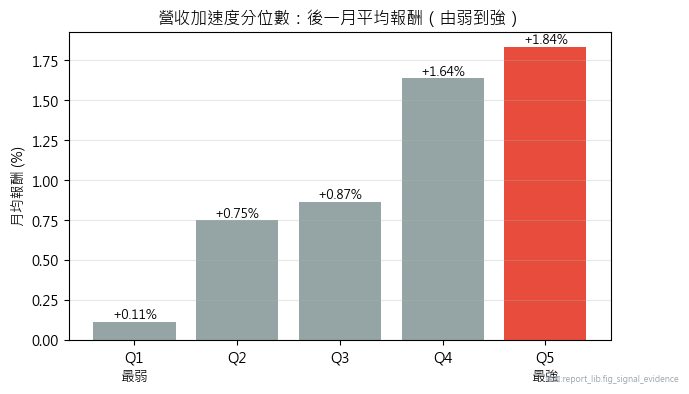

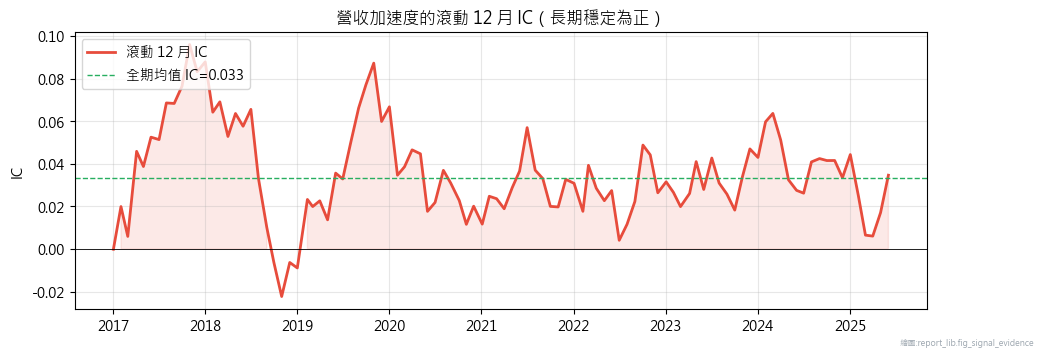

In [2]:
rm._preload_revenue(str(FINAL / "Data"))                     # 月營收(point-in-time)
accel = {}
for d in rb_full:
    a = {}
    for s in base_elig[d]:
        arr = rm._revenue_np_cache.get(s)
        if arr is None:
            continue
        e = rev_extra(arr, pd.Timestamp(d), 15)              # 近3月/近12月營收比,延遲15天(防未來函數)
        if e is not None and np.isfinite(e.get("rev_accel", np.nan)):
            a[s] = e["rev_accel"]
    accel[d] = pd.Series(a, dtype=float)

# 營收加速度的橫斷面預測力:分位數 spread + 滾動 12 月 IC
R.fig_signal_evidence(panel, rb, pool, ip, lambda d: accel[d].reindex(pd.Index(pool[d])), "營收加速度")

分位數由弱到強遞增、滾動 IC 長期為正（月均 IC 約 **+0.033**、$t\approx 3.1$，顯著）——**營收加速度確實能預測報酬**。

但有預測力的訊號，不等於好策略。若直接將它做成「每月買進營收加速度最強的一籃」，扣成本後表現平庸。成因有二：一是**只看財報、不看價格**，易選入「營收暴增、但股價尚未反應、甚至正在下跌」的股票，缺乏第二道把關；二是若**過度集中**，個股波動將直接傳入組合（具體數字見 §5.1）。**如何將一個平庸的訊號轉化為可實盤的策略，是第五章的主題。**

---

## 五、主策略、績效與歸因

第四章找到一個有預測力、但單獨平庸的訊號。本章將它轉化為策略：診斷其平庸的成因、補上第二個訊號（§5.1），展示完整績效（§5.2），最後拆解報酬、追究其來源（§5.3）。

### 5.1 主策略：雙動能

**診斷與修補。** 營收加速度單獨平庸，根因是「只看財報、不看價格」。補法是加上一條**結構完全不同**的動能訊號——**股價創新高**：設 $P_t$ 為換股日收盤、近一年滾動最高為分母，

$$f^{\text{ph}} = \frac{P_t}{\max\{P_{t-251},\ldots,P_t\}}\in(0,1],$$

愈接近 1 表股價愈貼近 52 週新高（只用過去 252 日收盤，無未來函數；此 52 週高動能在台股實證上優於經典的「12 個月減 1 個月」報酬動能）。兩個訊號截面相關僅約 +0.2、近乎正交：一個看價格、一個看基本面。

**主策略 ＝ 兩條動能的交集。** 取兩訊號截面名次（pct-rank）平均為複合分數，選前 **30 檔**、各檔等權、總曝險 95%；並設**選股遲滯**（已持有者複合分數仍在前 45 名即續抱）以抑制換手。本策略為純多頭（long-only）。下方為策略的關鍵程式（後續所有回測共用）：

In [3]:
price_nh = panel / panel.rolling(252).max()                  # 第二個訊號:股價創新高(52週高)

def make_wf(keys, use_pool=None, n=30, exit_rank=45):        # ★選股權重函數:keys⊆{p,a};名次平均→top n→遲滯
    P = use_pool if use_pool is not None else pool
    def wf(date, cw, nav):
        ts = pd.Timestamp(date); i = ip[ts]; syms = P.get(ts, [])
        if not syms:
            return cw or {}
        held = [s for s, w in (cw or {}).items() if w > 0.001]; uni = pd.Index(syms)
        cols = {}
        if "p" in keys: cols["p"] = price_nh.iloc[i].reindex(uni)        # 價格動能
        if "a" in keys: cols["a"] = accel[ts].reindex(uni)              # 基本面動能
        df = pd.DataFrame(cols).dropna(how="any")
        if len(df) < n:
            return cw or {}
        comp = df.rank(pct=True).mean(axis=1); rk = comp.rank(ascending=False)   # 截面名次平均=複合分數
        sel = sorted([s for s in held if s in rk.index and rk[s] <= exit_rank], key=lambda s: rk[s])[:n]  # 遲滯:已持有且仍在前exit_rank續抱
        for s in comp.sort_values(ascending=False).index:
            if len(sel) >= n:
                break
            if s not in sel:
                sel.append(s)
        return {x: 0.95 / len(sel) for x in sel} if sel else {}          # 選前 n、等權、曝險95%
    return wf

# 主策略與其單訊號分解(扣成本20/50,涵蓋開發期)
nav_mom, st_mom = simulate_nav(panel, rb, make_wf("pa"), 20.0, 50.0, sim_idx=sim)   # 雙動能(主策略)
nav_p = simulate_nav(panel, rb, make_wf("p"), 20.0, 50.0, sim_idx=sim)[0]           # 純股價創新高
nav_a = simulate_nav(panel, rb, make_wf("a"), 20.0, 50.0, sim_idx=sim)[0]           # 純營收加速度
nav_mom_full = simulate_nav(panel, rb_full, make_wf("pa"), 20.0, 50.0, sim_idx=sim_full)[0]  # 全期(含保留樣本),僅供主圖延伸

# 三基準(0050 / Top-50 大型股等權 / 等權可投資範圍):DEV(≤HI) + 全期版。等價於 top_n_equal_weight_nav、但快約3倍(見 report_lib)。
B = R.build_benchmarks(panel, vol, first_listed, rb_full, sim_full, HI, eligible_at, simulate_nav, buy_hold_etf, data)
nav_ew, nav_top50, nav_0050 = B["ew"], B["top50"], B["etf"]
nav_ew_full, nav_top50_full, nav_0050_full = B["ew_full"], B["top50_full"], B["etf_full"]

**確認效應。** 取「交集」的理由，是兩條動能單獨皆平庸、組合方強。拆回單一訊號看：

| 訊號 | 年化 $g$ |
|---|---:|
| 純股價創新高 | +12.2% |
| 純營收加速度 | +11.0% |
| **雙動能（組合）** | **+21.0%** |

單獨各約 11–12%，組合躍升到 21%——組合要求兩訊號**彼此確認**，濾掉「股價創高但營收沒跟上」或「營收暴增但股價沒反應」的單邊雜訊。這個躍升**不限於全期**：依 §2.2 的滾動原則檢視，滾動 36 月視窗中雙動能勝過兩個單訊號的比例達 **97%**（60 月視窗 **100%**），確認 gap（雙動能 − 較佳的單訊號）中位 +8pp、僅一個視窗為負——「1+1 遠大於 2」並非某段時期的假象，而是跨視窗穩健（這份「確認效應」屬建完策略才回頭看到的事後歸因，§5.3 會誠實討論）。

**為何不是加碼集中。** 此演進亦驗證了「將訊號做得更集中」無法補救平庸的因子。由最樸素的「營收加速度最強 15 檔」逐步演進至雙動能：

| 演進階段 | $g$ | CAGR | Sharpe | MDD | 年換手 |
|---|---:|---:|---:|---:|---:|
| 樸素加速度 top-15（單訊號·集中） | +10.0% | +10.5% | 0.50 | 50% | 9.9× |
| 加速度 top-30（單訊號·分散） | +11.0% | +11.6% | 0.56 | 44% | 7.6× |
| **雙動能 top-30（主策略）** | **+21.0%** | +23.3% | 1.00 | 32% | 10.9× |

先將持股 15→30 分散，最大回撤由 50% 收斂至 44%，但 $g$ 幾無變化——**分散降低風險、卻不增報酬**；真正的躍升源於加入第二個訊號作確認（$g$ 由 11% 升至 21%、回撤再降至 32%）。

### 5.2 績效

下方以三個各有意義的基準對照主策略——**0050**（真實可買的市值大盤，逾半權重在台積電）、**Top-50 大型股等權**（分散的被動大型股、無單一集中）、**等權可投資範圍**（同股池全等權、無選股技能，是最乾淨的「有無選股」對照）：

| 策略 | $g$ | CAGR | Sharpe | Sortino | MDD | Calmar | $\tfrac12\mathrm{SR}^2$ |
|---|---:|---:|---:|---:|---:|---:|---:|
| **雙動能（主策略）** | **+21.0%** | +23.3% | 1.00 | 1.26 | 32% | 0.72 | 50% |
| 0050 市值大盤 | +15.8% | +17.1% | 0.93 | 1.21 | 34% | 0.51 | 43% |
| Top-50 大型股等權 | +10.4% | +10.9% | 0.54 | 0.68 | 43% | 0.26 | 15% |
| 等權可投資範圍 | +11.0% | +11.6% | 0.77 | 0.79 | 32% | 0.37 | 30% |

年換手約 **10.9×**（月頻、低週轉，不依賴日內交易，具可實盤性）。

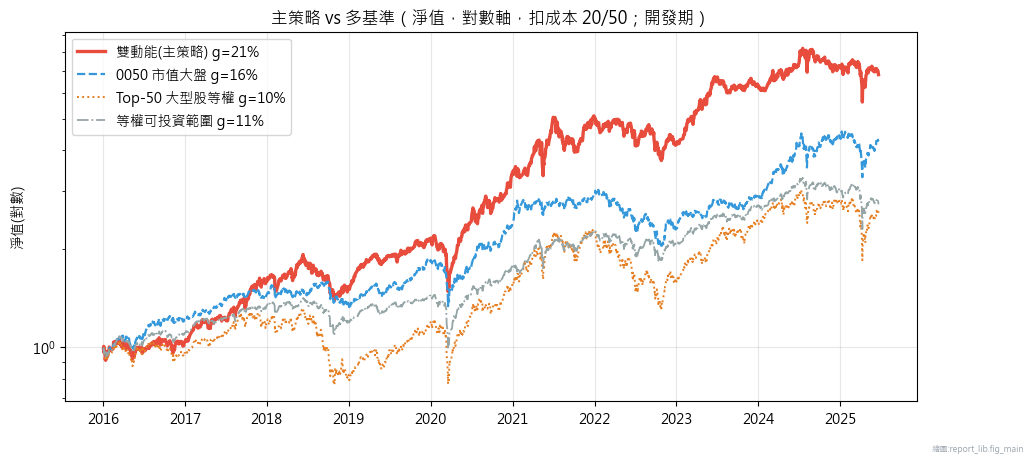

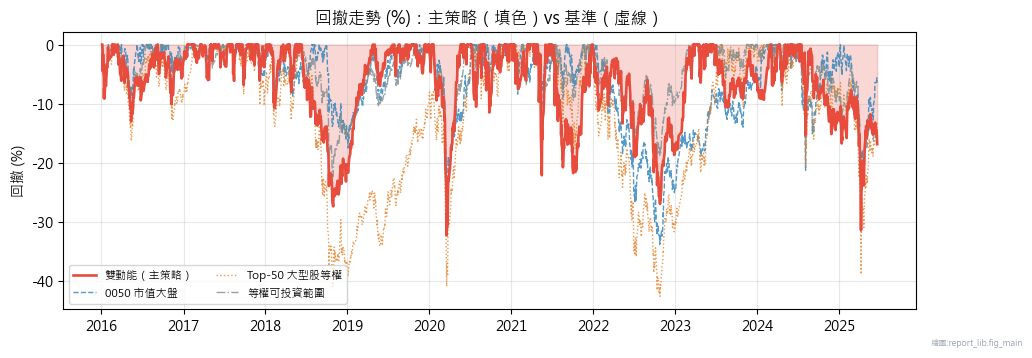

In [4]:
R.fig_main(nav_mom, nav_0050, nav_ew, nav_top50)   # 淨值(對數軸,開發期,多基準) / 回撤;鎖盒揭示見 §6.4

主策略年化 $g$ 約 **21%**，對三個基準皆領先（此全期數字僅為摘要；其跨視窗、跨 regime 的穩健性，依 §2.2 的原則於 §6.1 以滾動分佈檢視）。兩個被動等權基準的 $g$ 僅約 10–11%，明顯落後集中台積電的 0050（15.8%）——本樣本期權值股大盤強、分散等權弱。以下逐年觀察：

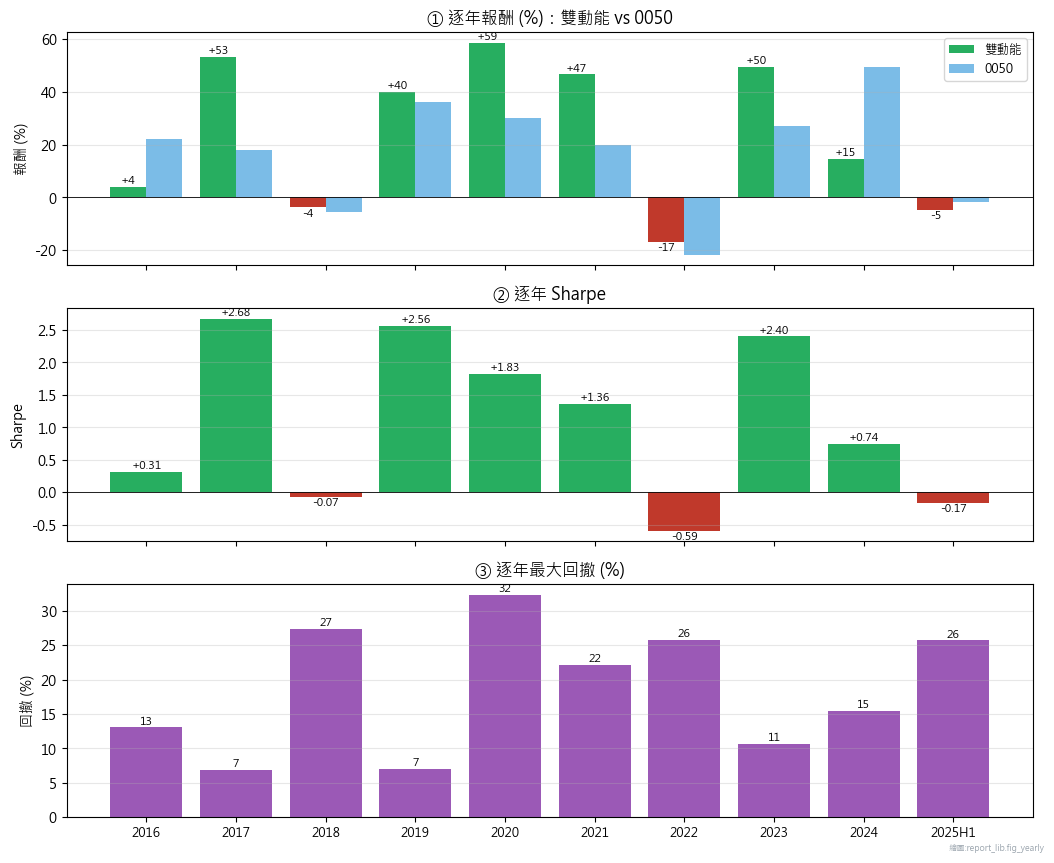

In [5]:
R.fig_yearly(nav_mom, nav_0050)   # 主策略逐年:報酬(對照0050) / Sharpe / 最大回撤

10 年中 **8 年正報酬**（2018 與 2025 上半年為負）。勝 0050 較多的年份（2017、2020、2021、2023）多為中小型與成長動能順風；落後 0050 的年份（2016、2024）則是台積電領軍的權值股單邊行情——這個「贏在中小型、輸在權值股大年」的型態，正預示 §5.3 的歸因。

### 5.3 報酬從哪來？

**歸因**把報酬拆開、追究來源：主策略的超額，是真正的選股技能，還是運氣、或對某種市場共通走向的曝險。本節分兩個層次回答。

**第一層（訊號層）：確認效應。** §5.1 已示：拆回兩條訊號，報酬主要來自「兩者互相確認」這個結構，而非任一訊號本身強——這是報酬來源的第一層答案。須強調，這是先建好策略、再回頭拆解才看到的**事後歸因**，而非事前設計的保證：沒有人能單憑事前的邏輯，斷定兩條訊號一旦交集便會產生如此強的效果。

**第二層（對照市場）：真實選股力，還是市場順風？** 主策略勝過大盤，但這份領先可能來自選股本領，也可能僅是某種市場共通走向的順風。基本工具是將策略報酬對大盤做迴歸：

$$r_{p,t}-r_f = \alpha + \beta\,(r_{m,t}-r_f) + \varepsilon_t,$$

$\beta$ 是隨大盤起伏的程度、$\alpha$ 是扣掉大盤連動後仍無法解釋的超額（「選股本領」的候選）。再把「大小型、便宜與否、獲利高低」等市場共通走向也加進迴歸（資產定價的標準工具，Fama–French 五因子），若 $\alpha$ 因此大幅縮小，表示原本的超額源自這些走向。三個關鍵數字（年化選股超額 $\alpha$）一覽如下：

| 拆解方式 | 選股超額 $\alpha$ | 是否顯著 |
|---|---:|:---:|
| 對大盤（CAPM） | +10% | 否（$t\approx1.6$） |
| 控制共通走向後（FF5） | +6% | 否（$t\approx1.2$） |
| 多空選股力（最看好 − 最看壞） | +31% | **是（$t\approx5.5$）** |

- **共通走向只能解釋一部分；殘差選股超額不小，但統計上未獲確認（前兩列）。** 控制 FF5 共通走向後，無法解釋的選股超額由 +10% 僅縮至約 **+6%**（這些走向約解釋三分之一），且 $t\approx1.2$、未達顯著——點估計可觀，卻無法在這段樣本（FF 因子窗 2018 起）內與零區分，且對因子建構敏感（財報覆蓋一變、點估計即在 +2%～+6% 間擺動），不宜過度解讀其量級。另須澄清一個直覺上的誤解：主策略雖**強烈偏向中小型股**（$\beta_{\text{SMB}}\approx1.0$），但本樣本期小型股整體**弱於**大型股（SMB 溢酬約 $-2\%$／年），故這個傾斜其實是**逆風、拖累約 $-2\%$／年**，而非順風；殘差選股 α 是在這道逆風下取得的。
- **選股本身確有真實能力，且在多空形式下高度顯著（第三列）。** 可直接驗證：買進訊號最看好的一籃、放空最看壞的一籃（抵銷大盤漲跌），兩者年化差約 31%，控制上述所有共通走向後**仍高度顯著（$t\approx5.5$）**。訊號**確能分辨贏家與輸家**——只是在純多頭、又重壓本期落後大盤的中小型族群時，這份選股力大半用於抵消族群逆風，故對大盤的「淨」領先看似溫和、long-only 殘差 α 也因樣本短而未達顯著。

誠實的定位是：**一份真實、但在純多頭形式下統計上尚未坐實的選股力**，且是在本期一個對中小型不利的族群環境中取得——它真實存在，卻既未被誇大，也不能化約為單純的市場共通走向曝險。

最後一項誠實的補充：本研究亦檢驗過**能否藉更多會預測報酬的因子改善績效**——系統性試驗數十個，無一能穩健提升 $g$。最「會預測」的那些（配息高、低波動、便宜），反而將組合導向防禦、低成長的股票：夏普值亮眼、$g$ 卻被拖低（正是 §4.1 的提醒，也是「選對目標函數」的實證）；何況它們的預測力多半**集中於個別年份**（如價值因子的優勢幾乎來自 2023 一個多頭大年），單一全期數字反而掩蓋了這種 regime 依賴（§2.2）。完整清單見 `Analysis/FACTOR_INVENTORY.md`。**簡約並非取巧，而是檢驗之後僅存的選擇。**

---

## 六、過擬合：試著弄垮這個策略

過去十年的亮眼數字，可能只是運氣，或是在多組設定中挑出的幸運兒。一個策略是否可信，不在於它有多好，而在於它**能否禁得起質疑**。本章對主策略提出四個問題，逐一檢驗：是否僅倚賴某段行情（§6.1）、對 0050 的領先是否統計上可辨識（§6.2）、參數與訊號是否事後挑選（§6.3，本章核心，由**回測過擬合機率 PBO**（§2.5）直接量化）、是否存在未受污染的樣本（§6.4）。四問皆過，方有理由相信績效並非過擬合的產物。

### 6.1 績效是否僅倚賴某一段行情？

將單一全期數字拆成滾動視窗檢視其分佈——每個 36／60 月視窗各計算一次 $g$：

| 視窗 | 視窗數 | 中位 $g$ | 第 5 百分位（最差視窗） | 勝 0050 比例 | 勝等權比例 |
|---|---:|---:|---:|---:|---:|
| 36 月 | 77 | +23.9% | +12.8% | 91% | 99% |
| 60 月 | 53 | +27.4% | +20.9% | 100% | 100% |

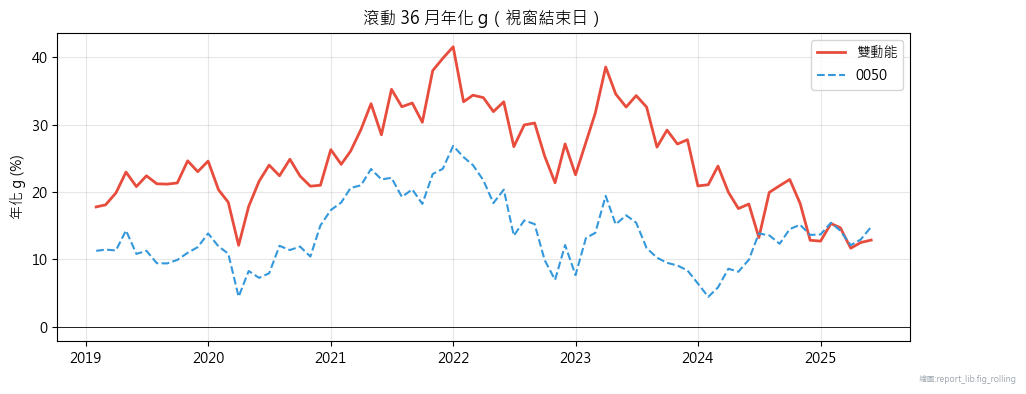

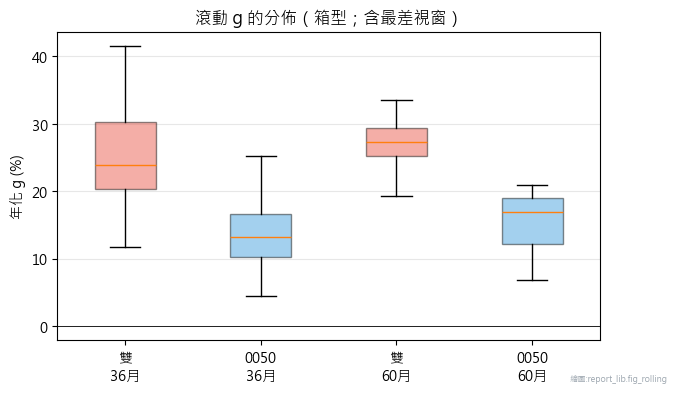

In [6]:
R.fig_rolling(nav_mom, nav_0050)   # 滾動 36 月 g 走勢 + 滾動 g 分佈箱型

再按市場狀態分期看年化 $g$：

| 期間 | 雙動能 $g$ | 0050 $g$ |
|---|---:|---:|
| 2016–2018 | +14.6% | +10.8% |
| 2019–2021 | +41.6% | +26.8% |
| 2022–2025H1 | +9.2% | +11.1% |

就這個問題而言，即使最差的 60 月視窗，$g$ 仍達 +20.9%、仍明顯領先 0050；勝基準的視窗比例亦極高。分期而言，動能於趨勢市（2019–2021）較強、於震盪市（2022 起）較弱，但**無任一時期為負，亦非倚賴單一時期支撐全局**。

### 6.2 對 0050 的領先，統計上是否可辨識？

以區塊自助法（尊重報酬自相關）重抽，計算雙動能對**各基準**的 $g$ 差 $\Delta g$ 之分佈：

| 對照基準 | $\Delta g$（年化） | 95% 信賴區間 | $p$ | 顯著？ |
|---|---:|:---:|---:|:---:|
| 0050 市值大盤 | +5.1% | $[-5.7\%,\ +17.5\%]$ | 0.33 | 否 |
| Top-50 大型股等權 | +10.6% | $[+1.3\%,\ +21.2\%]$ | 0.03 | **是** |
| 等權可投資範圍 | +10.0% | $[+1.9\%,\ +18.3\%]$ | 0.01 | **是** |

這裡須誠實、但完整地看。對 **0050** 的領先確實統計上難以確認（信賴區間涵蓋 0）——惟其根源，在於 0050 受台積電權重大幅推高，本就不是對等的比較基準。對兩個**公平基準**（同樣分散的大型股等權、全池等權），雙動能的領先**統計上顯著**（$p=0.01$、$0.03$）。換言之：未能超越「重壓台積電而受惠的 0050」是統計上的平手，但勝過「同樣分散、卻不施以選股的對照組」則屬紮實。如 §2.3 所述，約 10 年樣本下 $g$ 難達顯著，故判斷併看跨視窗一致性（§6.1）、經濟機制（§5.3）與此處對公平基準的顯著性。

### 6.3 參數與訊號是否為樣本內事後挑選？

這是「過擬合」最直接的一問，也是本章的核心。過擬合的真正自由度有二——**選用哪些訊號**與**參數如何調校**；本節以 PBO（§2.5）分別量化，再輔以 walk-forward 驗證。

**過擬合機率 PBO。** 對訊號層，設定空間取「營收算子 × 價格算子」的系統性矩陣（30 個雙訊號配對，另加 11 個單訊號、參數固定）；對參數層，取以選用設定為中心、**對稱展開**的網格（各維向兩側等幅，避免將選用值置於邊界而美化數字）。兩個層次的 PBO 如下，皆遠低於擲銅板的 0.5：

| 過擬合的自由度 | 設定空間 | PBO |
|---|---|---:|
| **訊號選擇** | 41 組算子配對 | **≈ 0.01–0.07** |
| **結構參數** | 45 組對稱網格 | **≈ 0.15** |

訊號層尤低，且選用之「營收加速度 ∩ 股價創新高」於 41 組中 $g$ 居首——可見確認效應屬**結構性**（多組動能配對皆可行、穩勝單一訊號），非此一配對的樣本內僥倖（惟此穩健以維持兩條訊號為限；§5.3 已述及，加入第三因子者無一能通過同等檢驗）。參數層略高，係因 45 組同屬一策略的微調、彼此相近，何者最佳本就帶有雜訊。

兩點誠實的補充：其一，選用設定並非樣本內最佳，其 $g$ 僅居網格中段（樣本內最高者為「5 千萬／20 檔」的 26.5%）；其二，若改採將選用值置於邊界的單邊網格，PBO 會降至約 0.11，反而失之樂觀，故此處取對稱網格的保守值。

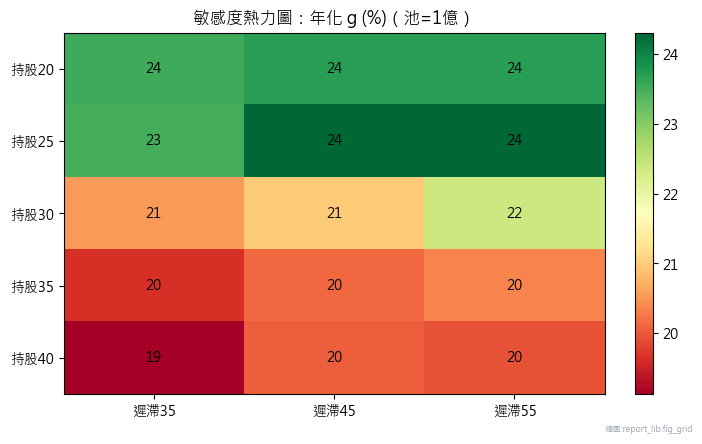

In [7]:
grid = R.compute_grid(panel, rb, sim, make_wf, pool_at, simulate_nav)   # 45 組對稱結構參數淨值(算一次,§6.3/§6.4 共用)
R.fig_grid(grid)   # 持股×遲滯敏感度熱力圖

**walk-forward 驗證。** 直接模擬實盤決策：每一年度僅以**過去**資料自 45 組中挑選 $g$ 最高者，向前套用一年，串成一條樣本外淨值：

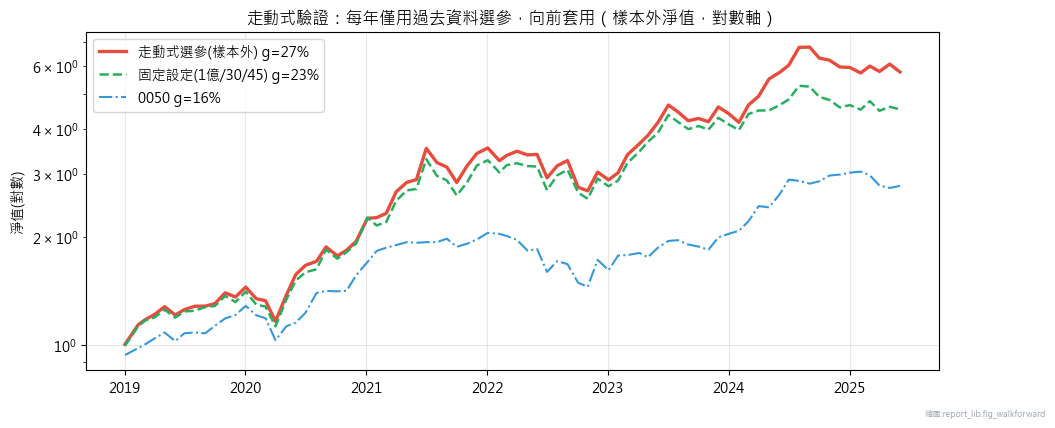

In [8]:
R.fig_walkforward(grid, rb, nav_0050)   # walk-forward:逐年僅用過去選參、向前套用

**四項證據一致。** 訊號層與參數層的 PBO 皆 $\ll 0.5$；熱力圖上選用值（30 檔、遲滯 45）居網格中央、四周為一片平台、無孤立尖峰；walk-forward「逐年現選參數」的樣本外曲線與固定設定相當、且同樣遠勝 0050。**即便不事後得知最佳訊號與參數、僅憑當下可得的歷史挑選，結論亦同**——績效並非事後挑揀的產物。

### 6.4 是否存在未受污染的樣本？

前三道仍在「開發期」內檢驗。最後一道最嚴：最近約 12 個月（2025-07 至 2026-05）自研究之初即**封存、全程不參與任何選擇**（§2.4 的保留樣本）——前述所有圖表與參數，皆未曾觸及。最後拆封、執行一次：主策略年化 $g$ 約 **100%**、夏普約 4.0、最大回撤僅約 7%，明顯勝過同期 0050（約 81%）。下圖呈現此 11 個月（兩者淨值各自重設為 1.0）：

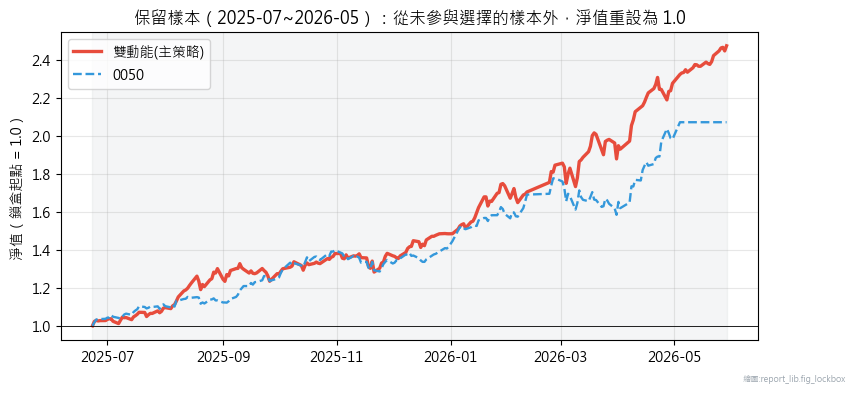

In [9]:
R.fig_lockbox(nav_mom_full, nav_0050_full, LOCK_START)   # 鎖盒揭示:從未污染的樣本外,雙動能 vs 0050

**結論須誠實看待。** 策略於此道未受污染的向前檢驗中**未失效、仍領先**。惟此窗恰為極端多頭順風（兩者 CAGR 皆逾 120%），故其確認的是**方向（策略未崩）**、而非絕對量級——保留樣本的價值，正在於它是一道未被任何選擇污染的向前檢驗。

**小結。** 四問逐一過關（統計顯著性為誠實的例外，已說明何以仍可信），這即是我們相信績效並非過擬合的理由。

---

## 七、限制

**報酬有 size 梯度、胃納有限（最重要的一項）。** 主策略的動能 edge 隨可投資池流動性門檻上升而遞減——部分是真實的中小型股溢酬。下圖掃描門檻由 5 千萬至 10 億，並標註各門檻的中位池檔數：

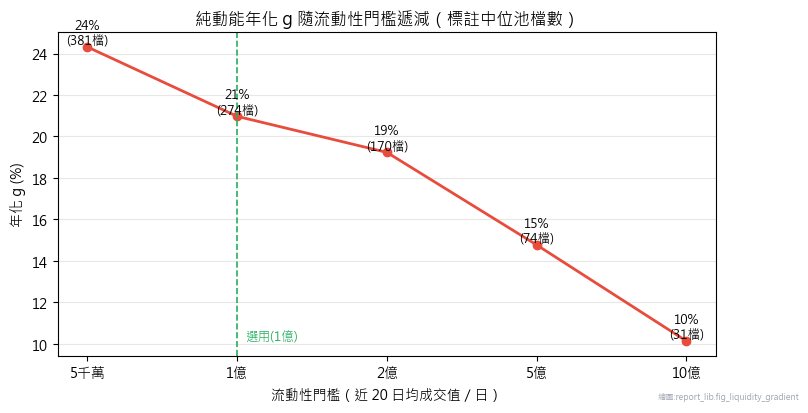

In [10]:
R.fig_liquidity_gradient(panel, rb, sim, make_wf, pool_at, simulate_nav)   # 純動能 g 隨流動性門檻的梯度

1 億是「膝點」——已過薄量區、仍保有幾乎全部 $g$；再提高門檻以擴大容量會稀釋 $g$。本策略胃納約 **17 億新台幣**（受限於尾端較不流動的持股），適合中小型資金。其餘限制：

- **$g$-edge 在約 10 年樣本內難達統計顯著**。主策略對 0050 的 $g$ 差為正，但自助法信賴區間涵蓋 0（§6.2）；判斷因此倚賴跨視窗一致性與經濟機制，而非單一 $p$ 值。
- **regime 依賴與尾端風險**。動能於趨勢市較強、於震盪市較弱；本期最大回撤約 30%（0050 約 34%），惟外推至開發期之前的 2008–2015 顯示，回撤**可深至約 60%**（海嘯期的動能崩盤，屬真實的尾端風險）。該段外推亦顯示：確認效應的**訊號基礎跨十年穩健**（營收加速度於動能股內的條件 IC 兩個十年皆約 +0.05），**惟其複利增益取決於橫斷面報酬的分化**——於高相關的危機期幾近於零、於分化的近十年方顯著（呼應 §4.1「IC≠g」）。
- **選股 α 受借券限制、只能部分變現**。多空價差顯著（§5.3），但要完整實現須放空最看壞的一籃，受台股中小型個股借券限制；純多頭是務實折衷。
- **回測不等於未來**。要真正驗證，需在實盤環境追蹤至少 6 個月以上的交易記錄。

---

## 八、結論

三項要點：

1. **可實盤策略是樸素的雙動能。** 「股價創新高 ∩ 營收加速度」取截面名次平均、選前 30、等權、設遲滯——兩條動能單獨平庸、組合方強（確認效應）；扣成本後全期年化 $g$ 約 **21%**，對 0050 穩定領先。

2. **報酬主要來自選股力，而非市場共通走向。** 控制市場與 FF5 共通走向後，殘差選股超額仍約 **+6%**／年（這些走向僅解釋約三分之一），惟 $t\approx1.2$、樣本內未達顯著；多空形式的選股超額則**高度顯著**（$t\approx5.5$）。其中主策略的中小型偏向，本期實為逆風而非順風（詳見 §5.3）。誠實的定位是：一份真實、但在 long-only 形式下尚未統計坐實的選股力，於不利小型股的環境中取得——既未被誇大，也不能化約為純粹的市場共通走向曝險。

3. **加入更多訊號無法穩健改善——簡約勝。** 數十種候選因子中，最「會預測報酬」的那些反而最拉低 $g$（將組合導向防禦、低成長股）；於夏普值下看似有效的種種微調，多為「犧牲報酬換平滑」的假象。

**小結（方法論收穫）。** 本報告的練習，是把量化研究中容易被跳過的一層先想清楚：先確立「要最佳化什麼」（對數成長率，而非夏普值）與「如何誠實檢驗」（滾動分佈／walk-forward／自助法／保留樣本），再談策略。同一套資料，換個目標函數與一套誠實的樣本外紀律，結論便大不相同——**重點往往不在找到多高的數字，而在誠實地知道哪些是真的**。

---

**參考文獻**

- Kelly, J. L. (1956). A New Interpretation of Information Rate. *Bell System Technical Journal*, 35(4).（對數成長率／凱利準則）
- George, T. & Hwang, C. (2004). The 52-Week High and Momentum Investing. *Journal of Finance*, 59(5).（52 週高動能；本報告的股價創新高訊號）
- Jegadeesh, N. & Titman, S. (1993). Returns to Buying Winners and Selling Losers. *Journal of Finance*, 48(1).（價格動能）
- DeMiguel, V., Garlappi, L. & Uppal, R. (2009). Optimal Versus Naive Diversification. *Review of Financial Studies*, 22(5).（等權勝最佳化／簡約）
- Grinold, R. & Kahn, R. (2000). *Active Portfolio Management* (2nd ed.). McGraw-Hill.（IC／ICIR 與資訊係數的判讀基準）
- Bailey, D., Borwein, J., López de Prado, M. & Zhu, Q. (2017). The Probability of Backtest Overfitting. *Journal of Computational Finance*, 20(4).（PBO／CSCV）
- Fama, E. & French, K. (2015). A Five-Factor Asset Pricing Model. *Journal of Financial Economics*, 116(1).（規模、評價、獲利、投資等共通走向的歸因；§5.3 用以辨別選股 vs 市場順風）

---

*資料來源：價格、月營收取自 FinMind（含已下市公司以避免倖存者偏差，現存股為還原股價；資料實際延伸至 2026-05）。報告涵蓋開發期 2016/1/1–2025/6/20（最近約一年為保留樣本，其樣本外結果見 §6.4），交易成本買進 20 bps／賣出 50 bps，營收訊號延遲 15 日。本 notebook 之可投資池、主策略回測、滾動分佈與圖表由 `../Backtest/` 與 `../Analysis/`、`report_lib.py` 即時重現。*